In [1]:
# Fase 1: Análise Exploratória - MNIST
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from collections import Counter

print("✅ Bibliotecas importadas!")
print(f"NumPy: {np.__version__}")

✅ Bibliotecas importadas!
NumPy: 2.4.6


In [2]:
# Carregar MNIST - USANDO PARSER='PANDAS' PARA EVITAR ERRO
print("🔄 Carregando dados MNIST...")
X, y = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=False, parser='pandas')

# Converter para numpy arrays
X = np.array(X)
y = np.array(y, dtype=int)

print(f"✅ Dados carregados!")
print(f"X shape: {X.shape} (imagens, pixels)")
print(f"y shape: {y.shape} (rótulos)")
print(f"Classes: {np.unique(y)}")

🔄 Carregando dados MNIST...
✅ Dados carregados!
X shape: (70000, 784) (imagens, pixels)
y shape: (70000,) (rótulos)
Classes: [0 1 2 3 4 5 6 7 8 9]


📊 Distribuição das classes (balanceamento):
Dígito 0: 6903 imagens (9.9%)
Dígito 1: 7877 imagens (11.3%)
Dígito 2: 6990 imagens (10.0%)
Dígito 3: 7141 imagens (10.2%)
Dígito 4: 6824 imagens (9.7%)
Dígito 5: 6313 imagens (9.0%)
Dígito 6: 6876 imagens (9.8%)
Dígito 7: 7293 imagens (10.4%)
Dígito 8: 6825 imagens (9.8%)
Dígito 9: 6958 imagens (9.9%)


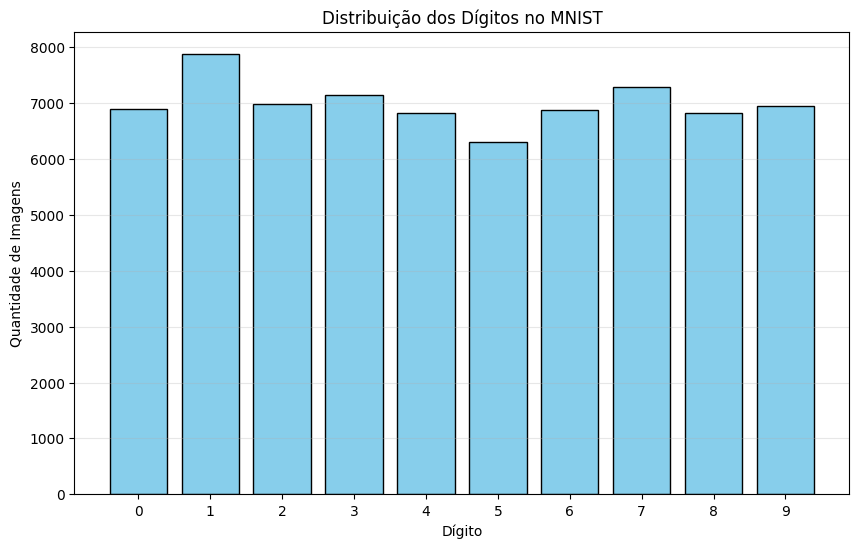


✅ Classes bem balanceadas (cerca de 10% cada)!


In [3]:
# Verificar balanceamento das classes
contagem = Counter(y)
print("📊 Distribuição das classes (balanceamento):")
for digit in sorted(contagem.keys()):
    print(f"Dígito {digit}: {contagem[digit]} imagens ({contagem[digit]/len(y)*100:.1f}%)")

# Gráfico de barras
plt.figure(figsize=(10, 6))
plt.bar(contagem.keys(), contagem.values(), color='skyblue', edgecolor='black')
plt.title('Distribuição dos Dígitos no MNIST')
plt.xlabel('Dígito')
plt.ylabel('Quantidade de Imagens')
plt.xticks(range(10))
plt.grid(axis='y', alpha=0.3)
plt.show()

print("\n✅ Classes bem balanceadas (cerca de 10% cada)!")

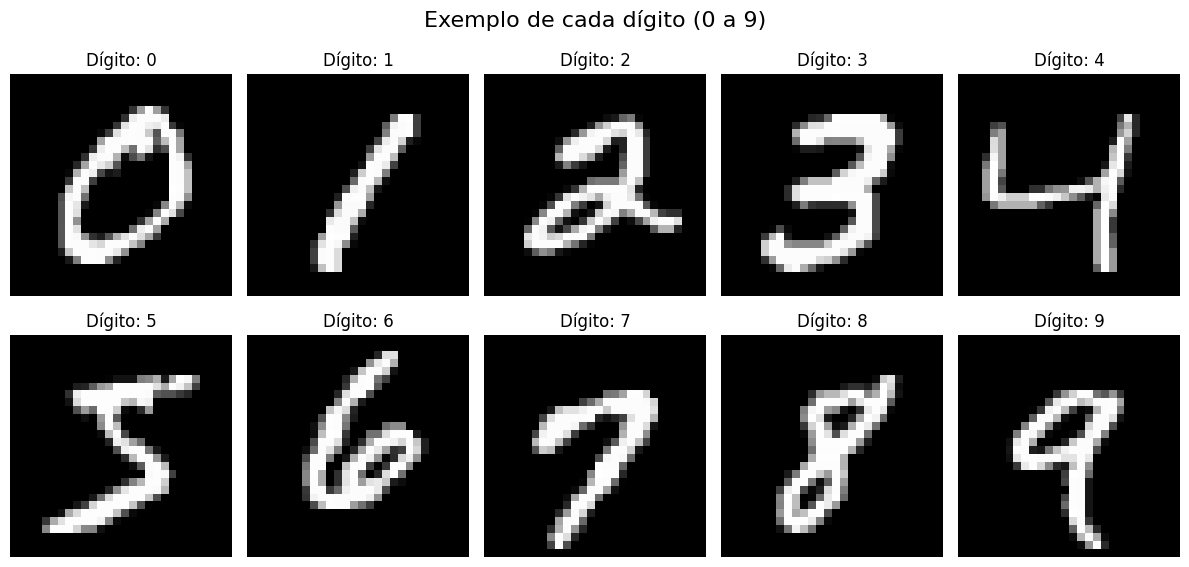

In [4]:
# Grade 2x5 mostrando um exemplo de cada dígito
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
axes = axes.ravel()

for i in range(10):
    # Encontrar o primeiro índice de cada dígito
    idx = np.where(y == i)[0][0]
    imagem = X[idx].reshape(28, 28)
    
    axes[i].imshow(imagem, cmap='gray')
    axes[i].set_title(f'Dígito: {i}')
    axes[i].axis('off')

plt.suptitle('Exemplo de cada dígito (0 a 9)', fontsize=16)
plt.tight_layout()
plt.show()

## 📝 Documentação - MNIST Dataset

### Escala de Pixels
- Os pixels variam de **0 (preto)** a **255 (branco)**.
- A normalização para [0, 1] será feita na próxima fase para melhorar a convergência.

### Estrutura dos Dados
- Cada imagem original é uma matriz de **28x28 pixels** (784 pixels no total).
- Para o treinamento, essas matrizes são "achatadas" (flattened) em **vetores de 784 features**.
- Isso permite que algoritmos de machine learning processem os dados como entradas numéricas.

### Distribuição
- O dataset tem **70.000 imagens** (60.000 treino, 10.000 teste).
- As 10 classes (dígitos 0-9) são **balanceadas**, com cerca de 7.000 exemplos cada.